# Exploratory Data Analysis

**Kronos Intelligence Portfolio Series | Project 01**

# Early Identification of At-Risk Students Using Predictive Analytics

**Author:** Tessa Gonzalez  
**Organization:** Kronos Intelligence  
**Notebook:** 03 – Exploratory Data Analysis

---

## Project Overview

Exploratory Data Analysis (EDA) is the process of examining, summarizing, and visualizing data to better understand its characteristics, identify meaningful patterns, and generate insights that support predictive modeling.

This notebook explores the cleaned student academic performance dataset to identify relationships among demographic, behavioral, and academic variables. The findings from this analysis will inform feature engineering, model development, and executive reporting in later phases of the project.

# Project Objectives

The objectives of this notebook are to:

- Explore the distribution of numerical and categorical variables.
- Examine the target variable (`passed`) to understand class balance.
- Identify relationships among academic, behavioral, and demographic features.
- Detect trends that may influence student performance.
- Generate insights to support feature engineering and predictive modeling.
- Document observations that may inform future governance decisions.

# Import Required Libraries

The following libraries provide the functionality required for data analysis, statistical summaries, and data visualization throughout the exploratory analysis process.

In [4]:
# ==========================================================
# Project Environment Setup
# ==========================================================

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

# Improve plot appearance
plt.rcParams["figure.figsize"] = (10,6)

# Set a consistent visual style
sns.set_theme(style="whitegrid")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_ROOT = "/content/drive/MyDrive/Kronos Intelligence/Student Performance Classification"

PROCESSED_DATA = os.path.join(PROJECT_ROOT, "data", "processed")

Mounted at /content/drive


# Load the Clean Dataset

The validated dataset produced during the Data Cleaning phase is loaded for exploratory analysis.

Using the cleaned dataset ensures that all subsequent analyses are based on validated and documented data.

In [7]:
clean_df = pd.read_csv(
    os.path.join(PROCESSED_DATA, "students_clean.csv")
)

clean_df.head()

,student_id,age,gender,ethnicity,parental_education,family_income,school_type,school_region,study_hours_per_week,attendance_rate,...,has_laptop,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
0,STU00000,15,M,B,phd,low,private,urban,2.0,91.7,...,yes,8.2,3.3,1.8,70.7,58.3,88.9,74.5,2.80,1
1,STU00001,23,F,A,phd,low,private,urban,14.2,76.8,...,yes,5.4,4.9,5.8,66.1,83.9,94.5,83.6,3.29,1
2,STU00002,22,F,B,bachelor,middle,public,suburban,3.3,83.1,...,yes,5.5,3.5,6.1,51.3,71.8,78.9,71.2,2.93,1
3,STU00003,19,M,D,some_college,high,public,suburban,17.9,72.8,...,yes,5.3,8.5,7.2,100.0,95.7,82.9,69.4,3.34,1
4,STU00004,19,M,C,some_college,middle,public,suburban,12.9,83.0,...,yes,7.5,1.0,4.5,87.5,73.0,88.5,74.8,3.27,1


# Review of Notebook 02

The Data Cleaning phase validated the integrity of the dataset and confirmed that it is suitable for exploratory analysis.

Key findings included:

- No missing values
- No duplicate records
- Appropriate data types
- Consistent categorical variables
- Potential outliers reviewed and retained
- Clean dataset prepared for analysis

This notebook builds upon those findings by investigating relationships, trends, and patterns that support predictive modeling.

# Exploratory Analysis Strategy

The purpose of exploratory data analysis is to understand the characteristics of the dataset before developing predictive models.

This notebook will address the following business questions:

1. How are student performance outcomes distributed?
2. Which academic and behavioral factors appear related to student success?
3. Are there meaningful relationships among numerical variables?
4. Do demographic characteristics show observable trends?
5. Which variables appear to be the strongest candidates for predictive modeling?

Each section includes visualizations, statistical summaries, business interpretations, and governance observations where appropriate.

# Target Variable Analysis

## Business Question

**How are students distributed between passing and failing?**

Understanding the distribution of the target variable is an essential first step in a classification project. Class balance influences model selection, evaluation metrics, and the overall reliability of predictive performance.

A balanced target variable generally supports more robust machine learning models, while significant imbalance may require additional preprocessing techniques such as resampling or class weighting.

In [8]:
# ==========================================================
# Target Variable Distribution
# ==========================================================

target_counts = clean_df["passed"].value_counts().sort_index()

target_counts

,count
passed,
0,390
1,9610


In [9]:
# ==========================================================
# Target Variable Percentages
# ==========================================================

target_percent = (
    clean_df["passed"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_percent

,proportion
passed,
0,3.9
1,96.1


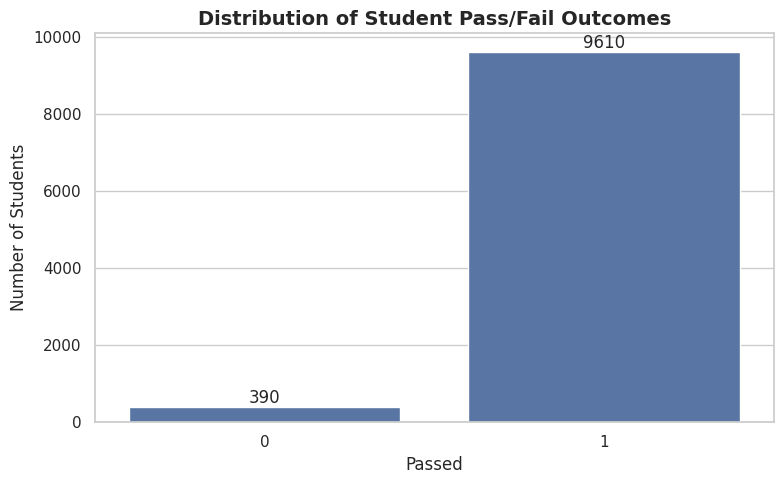

In [32]:
# ==========================================================
# Target Variable Visualization
# ==========================================================

plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=clean_df,
    x="passed"
)

plt.title(
    "Distribution of Student Pass/Fail Outcomes",
    fontsize=14,
    weight="bold"
)

plt.xlabel("Passed")
plt.ylabel("Number of Students")

# Add value labels
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()

# ==========================================================
# Save figure for GitHub README
# ==========================================================

IMAGE_DIR = os.path.join(PROJECT_ROOT, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

plt.savefig(
    os.path.join(IMAGE_DIR, "pass_fail_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [11]:
# ==========================================================
# Target Variable Summary Table
# ==========================================================

target_summary = pd.DataFrame({
    "Count": clean_df["passed"].value_counts().sort_index(),
    "Percent": (
        clean_df["passed"]
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )
})

target_summary

,Count,Percent
passed,,
0,390,3.9
1,9610,96.1


# Distribution Analysis

## Business Question

**What do the distributions of the key numerical variables reveal about student behavior and academic performance?**

Understanding how numerical variables are distributed provides insight into the characteristics of the dataset and helps identify potential patterns, skewness, clustering, and unusual observations.

This analysis focuses on variables that are expected to influence academic success:

- Overall GPA
- Study Hours per Week
- Attendance Rate
- Motivation Score
- Stress Level
- Sleep Hours

For each variable, a histogram with a kernel density estimate (KDE) is used to visualize the distribution, followed by a business interpretation and discussion of its potential impact on predictive modeling.

## Overall GPA

### Business Question

How are students' GPAs distributed across the population?

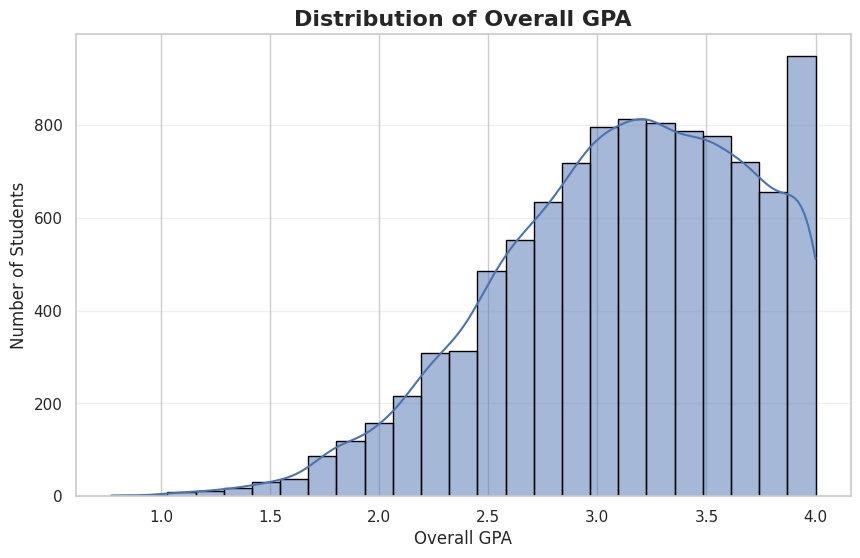

In [12]:
# ==========================================================
# Distribution of Overall GPA
# ==========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df,
    x="overall_gpa",
    bins=25,
    kde=True,
    edgecolor="black"
)

plt.title(
    "Distribution of Overall GPA",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Overall GPA")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Overall GPA Interpretation

The distribution of overall GPA illustrates how academic performance is spread across the student population.

**Business Impact**

Understanding the GPA distribution provides insight into whether academic performance is concentrated around average values or whether distinct groups of high- and low-performing students exist.

**Predictive Modeling Consideration**

If the distribution is approximately normal, GPA is likely to be a stable predictor. If the distribution is skewed or contains multiple clusters, additional feature engineering may improve model performance.

## Study Hours per Week

### Business Question

How are weekly study hours distributed across the student population?

Study time is a key behavioral indicator that may influence academic performance. Examining the distribution of study hours helps identify typical study patterns, variation among students, and whether the dataset contains groups of students with substantially different study habits.

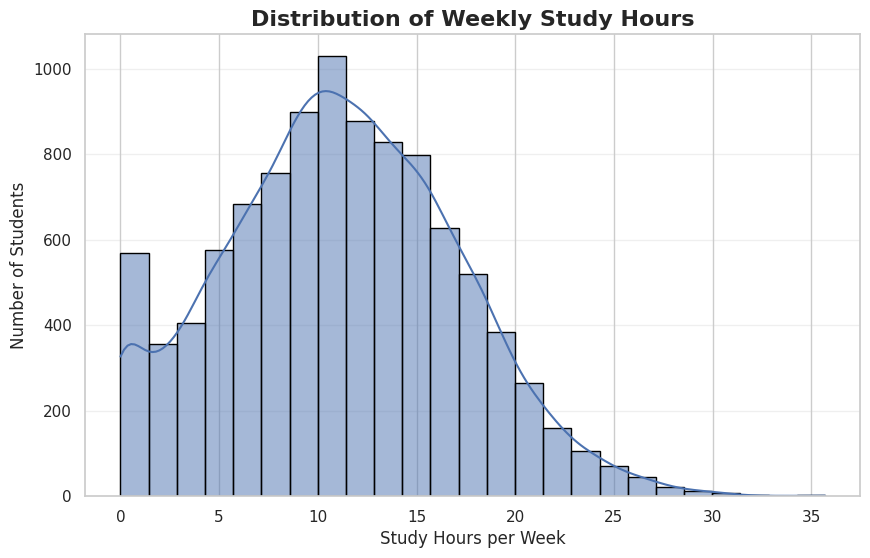

In [13]:
# ==========================================================
# Distribution of Study Hours
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    data=clean_df,
    x="study_hours_per_week",
    bins=25,
    kde=True,
    edgecolor="black"
)

plt.title(
    "Distribution of Weekly Study Hours",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Interpretation

The distribution of weekly study hours is **unimodal** and exhibits a **slight positive (right) skew**. Most students study between **8 and 16 hours per week**, with the highest concentration occurring around **10 to 12 hours**.

The long right tail indicates that while a small number of students study more than 20 hours per week, these students are relatively uncommon. There are also fewer students reporting very low study hours, although a small group appears near zero hours.

Overall, the distribution suggests that the majority of students maintain a moderate and consistent study schedule, while a smaller subset demonstrates either exceptionally high or exceptionally low study commitments.

### Business Impact

The concentration of students around moderate study hours suggests that typical study behavior is relatively consistent across the population. Students with unusually low or unusually high study hours may represent groups that warrant additional investigation. For example, students who study very little may benefit from academic support services, while those studying substantially more than average may indicate increased academic demands or different learning strategies.

### Predictive Modeling Consideration

Because study hours display meaningful variation across the student population, this variable is likely to provide useful predictive information when combined with other academic and behavioral factors. The slight right skew is not severe enough to require immediate transformation, but the variable should be evaluated further during correlation analysis to determine its relationship with GPA and the pass/fail outcome.

> **Key Insight**
>
> Most students study approximately **10–12 hours per week**, making study time a promising behavioral feature for predicting academic performance. The presence of a small number of students with exceptionally high or low study hours may provide additional insight into differences in academic outcomes.

## Attendance Rate

### Business Question

How are student attendance rates distributed?

Regular attendance is commonly associated with improved academic outcomes. Understanding the distribution of attendance rates provides insight into student engagement and may reveal whether attendance is likely to serve as an important predictor of academic success.

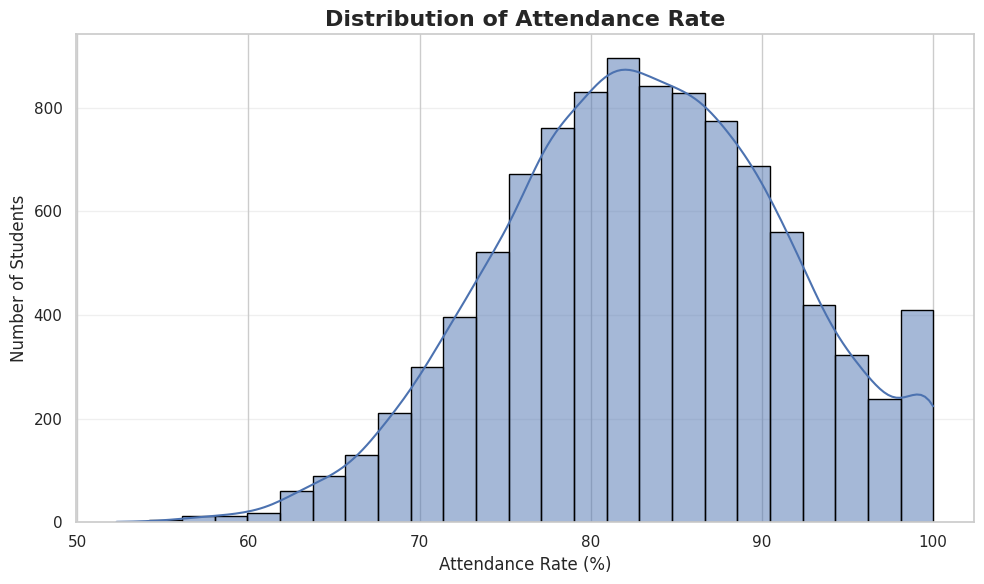

In [14]:
# ==========================================================
# Distribution of Attendance Rate
# ==========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df,
    x="attendance_rate",
    bins=25,
    kde=True,
    edgecolor="black"
)

plt.title(
    "Distribution of Attendance Rate",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Attendance Rate (%)")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [15]:
# Summary statistics for attendance rate
clean_df["attendance_rate"].describe()

,attendance_rate
count,10000.000000
mean,83.044980
std,8.345282
min,52.300000
25%,77.300000
50%,83.000000
75%,88.900000
max,100.000000


### Interpretation

The distribution of attendance rates is **unimodal** and approximately **bell-shaped**, with a slight **negative (left) skew**. Most students maintain attendance rates between **75% and 90%**, with the highest concentration centered around **82% to 85%**.

The distribution indicates that high attendance is common within the student population, while relatively few students have attendance rates below 70%. A small concentration of students appears at or near **100% attendance**, suggesting that perfect or near-perfect attendance is achieved by a subset of the population.

Overall, the distribution demonstrates that the majority of students consistently attend classes, with only a small proportion exhibiting substantially lower attendance.

### Business Impact

High attendance levels suggest strong overall student engagement within the population. Students with lower attendance rates may represent an at-risk group that could benefit from early intervention programs, academic advising, or attendance monitoring initiatives. Understanding attendance patterns allows educational institutions to identify students who may require additional support before academic performance declines.

### Predictive Modeling Consideration

Attendance rate appears to be a strong candidate for predictive modeling because it demonstrates substantial variation while remaining concentrated around higher values. Since attendance is frequently associated with academic success, this variable should be evaluated during correlation analysis to determine its relationship with overall GPA and the pass/fail outcome. Although the distribution is not perfectly normal, it does not exhibit extreme skewness that would require immediate transformation.

> **Key Insight**
>
> Most students maintain attendance rates above **75%**, with the largest concentration between **82% and 85%**. The relatively small group of students with low attendance may provide valuable information for identifying individuals at risk of academic difficulty and could become an important predictor in the classification model.

## Motivation Score

### Business Question

How are motivation scores distributed across the student population?

Student motivation is an important behavioral factor that may influence learning outcomes. Examining the distribution of motivation scores helps identify whether motivation levels are concentrated within a particular range or vary substantially across students.

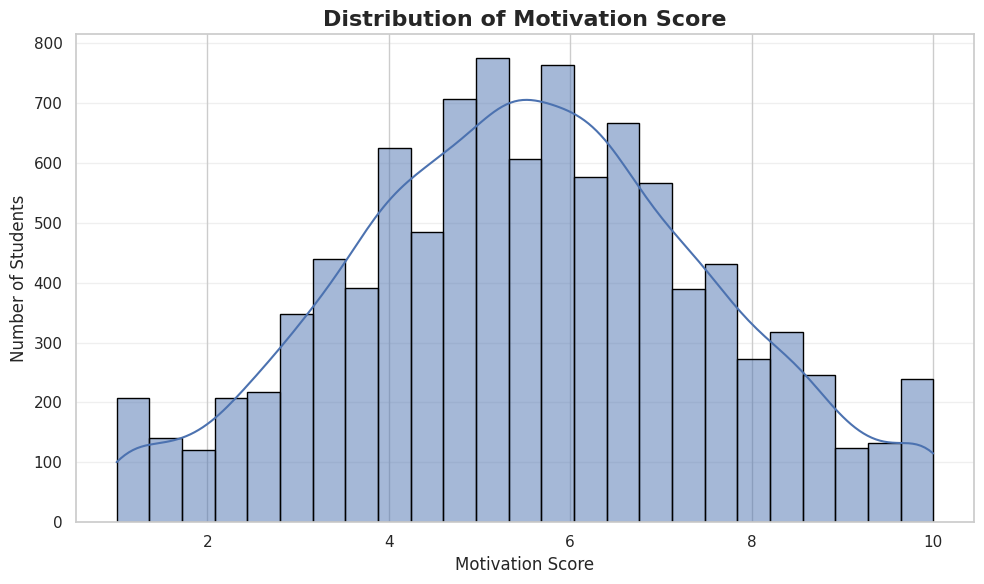

In [16]:
# ==========================================================
# Distribution of Motivation Score
# ==========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df,
    x="motivation_score",
    bins=25,
    kde=True,
    edgecolor="black"
)

plt.title(
    "Distribution of Motivation Score",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Motivation Score")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [17]:
# Summary statistics for motivation score
clean_df["motivation_score"].describe()

,motivation_score
count,10000.000000
mean,5.524950
std,2.011639
min,1.000000
25%,4.100000
50%,5.500000
75%,6.900000
max,10.000000


### Interpretation

The distribution of motivation scores is **unimodal** and approximately **bell-shaped**, with the highest concentration of students scoring between **4 and 7**. The peak of the distribution occurs around a motivation score of **5 to 6**, indicating that most students report moderate levels of academic motivation.

The distribution extends across the full range of scores, from approximately **1 to 10**, suggesting meaningful variation in student motivation throughout the population. Small groups of students are observed at both the lower and upper ends of the scale, indicating that while most students exhibit moderate motivation, some report either very low or very high levels of motivation.

Overall, the distribution suggests that motivation varies naturally across the student population without exhibiting substantial skewness or unusual clustering.

### Business Impact

Motivation is an important behavioral characteristic that may influence study habits, attendance, persistence, and ultimately academic performance. The broad range of motivation scores suggests that universities could benefit from identifying students with lower motivation levels and providing targeted academic support, mentoring, or engagement initiatives to improve student success.

### Predictive Modeling Consideration

The approximately symmetric distribution and broad range of motivation scores indicate that this variable is well suited for predictive modeling. Because motivation demonstrates meaningful variation without excessive skewness, it is likely to contribute useful information when combined with academic and behavioral variables such as study hours, attendance, and sleep habits. Further analysis will determine the strength of its relationship with overall GPA and the pass/fail outcome.

> **Key Insight**
>
> Most students report **moderate motivation levels**, with the largest concentration occurring between **scores of 4 and 7**. The wide distribution suggests that motivation may be an informative behavioral predictor and should be evaluated further during the correlation and feature relationship analyses.

## Stress Level

### Business Question

How are student stress levels distributed?

Stress can influence concentration, academic performance, and overall well-being. Analyzing the distribution of stress levels helps determine whether most students experience similar levels of stress or whether distinct patterns exist within the population.

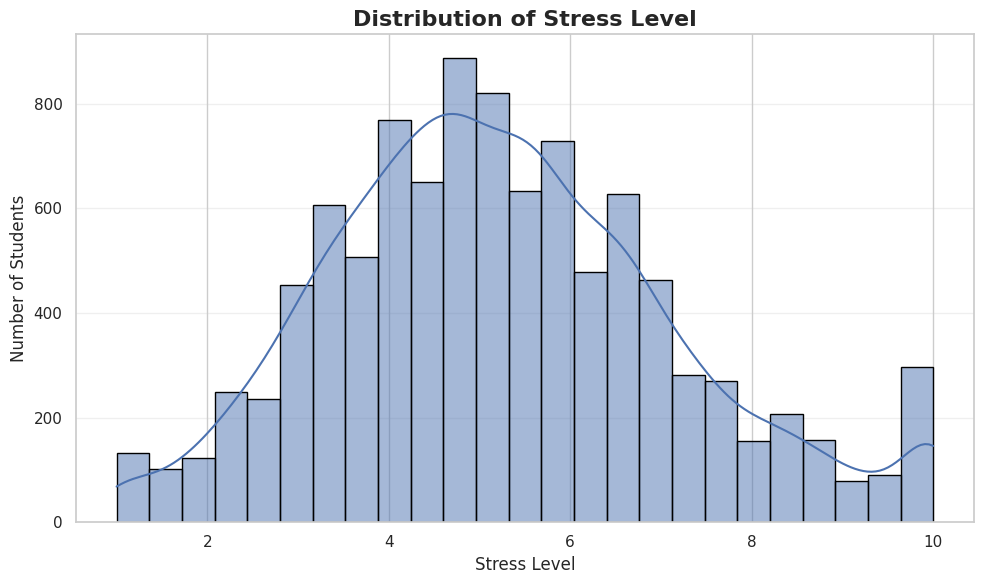

In [18]:
# ==========================================================
# Distribution of Stress Level
# ==========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df,
    x="stress_level",
    bins=25,
    kde=True,
    edgecolor="black"
)

plt.title(
    "Distribution of Stress Level",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Stress Level")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [19]:
# Summary statistics for stress level
clean_df["stress_level"].describe()

,stress_level
count,10000.00000
mean,5.23876
std,1.91925
min,1.00000
25%,3.90000
50%,5.10000
75%,6.40000
max,10.00000


### Interpretation

The distribution of stress levels is **unimodal** with a **slight positive (right) skew**. Most students report stress levels between **4 and 6**, with the highest concentration centered around **5**, indicating that moderate stress is common across the student population.

The distribution gradually tapers toward higher stress levels, with fewer students reporting stress levels above **8**. Likewise, relatively few students report very low stress levels below **2**. This pattern suggests that while extreme stress is uncommon, a meaningful subset of students experiences elevated stress that may warrant additional attention.

Overall, the distribution indicates that moderate stress is typical among students, while high stress is experienced by a smaller proportion of the population.

### Business Impact

Stress can influence concentration, motivation, sleep quality, and overall academic performance. Students experiencing elevated stress levels may be at greater risk of reduced academic achievement and could benefit from targeted wellness programs, counseling services, or academic support initiatives. Understanding stress patterns enables educational institutions to proactively identify and assist students who may be at risk.

### Predictive Modeling Consideration

Stress level demonstrates meaningful variation across the student population and is expected to complement other behavioral variables such as motivation, study hours, attendance, and sleep habits. Although the distribution exhibits a slight positive skew, it does not appear to require transformation prior to model development. Correlation analysis will determine whether stress contributes significant predictive value for overall GPA and pass/fail outcomes.

> **Key Insight**
>
> Most students report **moderate stress levels**, with the largest concentration occurring around **levels 4 to 6**. While extremely high stress is relatively uncommon, students reporting elevated stress may represent an important group for early intervention and could provide valuable predictive information when combined with other behavioral indicators.

## Sleep Hours

### Business Question

How are students' average sleep hours distributed?

Adequate sleep plays an important role in cognitive performance, memory, and overall health. Understanding the distribution of sleep hours provides insight into students' sleep habits and their potential relationship with academic success.

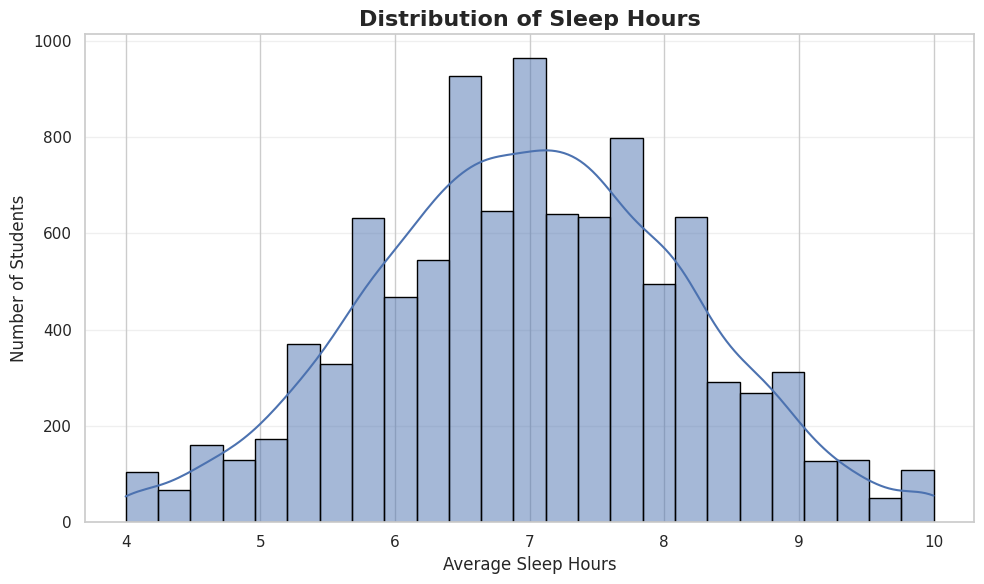

In [20]:
# ==========================================================
# Distribution of Sleep Hours
# ==========================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=clean_df,
    x="sleep_hours",
    bins=25,
    kde=True,
    edgecolor="black"
)

plt.title(
    "Distribution of Sleep Hours",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Average Sleep Hours")
plt.ylabel("Number of Students")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

### Interpretation

The distribution of average sleep hours is **approximately bell-shaped** and centered around **7 hours per night**, indicating that most students maintain relatively consistent sleep habits. The majority of observations fall between **6 and 8 hours**, with progressively fewer students reporting either very low or very high amounts of sleep.

The distribution appears relatively symmetric, although a small number of students report fewer than **5 hours** or more than **9 hours** of sleep. These observations represent natural variation within the student population rather than obvious anomalies.

Overall, the distribution suggests that most students obtain a moderate amount of sleep, while only a limited number experience extreme sleep patterns.

### Business Impact

Sleep plays a critical role in learning, memory consolidation, concentration, and overall well-being. Students who consistently obtain insufficient sleep may experience reduced academic performance, decreased classroom engagement, and increased stress. Understanding sleep patterns can help educational institutions identify students who may benefit from wellness initiatives or academic support programs that encourage healthy sleep habits.

### Predictive Modeling Consideration

Average sleep hours demonstrate meaningful variation while maintaining a relatively normal distribution, making this variable well suited for predictive modeling. Because sleep is closely related to cognitive performance and overall student well-being, it should be evaluated alongside behavioral variables such as study hours, motivation, attendance, and stress level to determine its contribution to predicting academic success.

> **Key Insight**
>
> Most students average **6 to 8 hours of sleep per night**, with the distribution centered near **7 hours**. This relatively balanced distribution suggests that sleep habits may provide valuable predictive information when combined with other academic and behavioral characteristics.

## Distribution Analysis Summary

The numerical variables examined in this section generally exhibit well-behaved distributions with no evidence of severe skewness or widespread anomalies.

Several important observations emerged:

- Most students report moderate study habits, motivation levels, stress levels, and sleep duration.
- Attendance rates are generally high across the student population.
- Overall GPA is concentrated around typical academic performance levels with natural variation.
- The distributions suggest that the dataset is well suited for predictive modeling without requiring extensive transformation of these variables.

These findings establish a strong foundation for the next phase of exploratory analysis, which will examine relationships among variables through correlation analysis and identify the factors most closely associated with student academic success.

# Correlation Analysis

## Business Question

**Which numerical variables demonstrate the strongest relationships with academic performance?**

Correlation analysis measures the strength and direction of linear relationships between numerical variables. Identifying these relationships helps determine which features are most closely associated with student success and may provide valuable predictive information during model development.

This analysis focuses on numerical variables that may influence academic performance, including study habits, attendance, motivation, stress, sleep, and assessment scores.

In [21]:
# ==========================================================
# Correlation Matrix
# ==========================================================

numerical_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
)

correlation_matrix = numerical_columns.corr()

correlation_matrix.round(2)

,age,study_hours_per_week,attendance_rate,extracurricular_activities,tutoring_sessions,sleep_hours,stress_level,motivation_score,reading_score,writing_score,math_score,science_score,overall_gpa,passed
age,1.00,-0.01,-0.00,-0.00,0.01,-0.01,0.00,-0.00,-0.01,-0.00,-0.01,0.00,-0.00,-0.01
study_hours_per_week,-0.01,1.00,0.01,0.00,-0.01,0.00,0.12,-0.01,0.49,0.50,0.57,0.55,0.58,0.22
attendance_rate,-0.00,0.01,1.00,-0.01,-0.01,-0.01,-0.00,0.34,0.27,0.29,0.28,0.28,0.31,0.14
extracurricular_activities,-0.00,0.00,-0.01,1.00,-0.00,-0.00,0.02,-0.01,-0.02,-0.01,-0.01,-0.01,-0.02,-0.01
tutoring_sessions,0.01,-0.01,-0.01,-0.00,1.00,-0.01,0.01,-0.00,-0.02,-0.02,-0.03,-0.02,-0.03,-0.04
sleep_hours,-0.01,0.00,-0.01,-0.00,-0.01,1.00,-0.34,-0.01,0.15,0.17,0.16,0.16,0.18,0.13
stress_level,0.00,0.12,-0.00,0.02,0.01,-0.34,1.00,-0.01,-0.20,-0.21,-0.19,-0.20,-0.22,-0.16
motivation_score,-0.00,-0.01,0.34,-0.01,-0.00,-0.01,-0.01,1.00,0.26,0.27,0.26,0.27,0.29,0.12
reading_score,-0.01,0.49,0.27,-0.02,-0.02,0.15,-0.20,0.26,1.00,0.68,0.68,0.68,0.84,0.40
writing_score,-0.00,0.50,0.29,-0.01,-0.02,0.17,-0.21,0.27,0.68,1.00,0.68,0.68,0.84,0.40


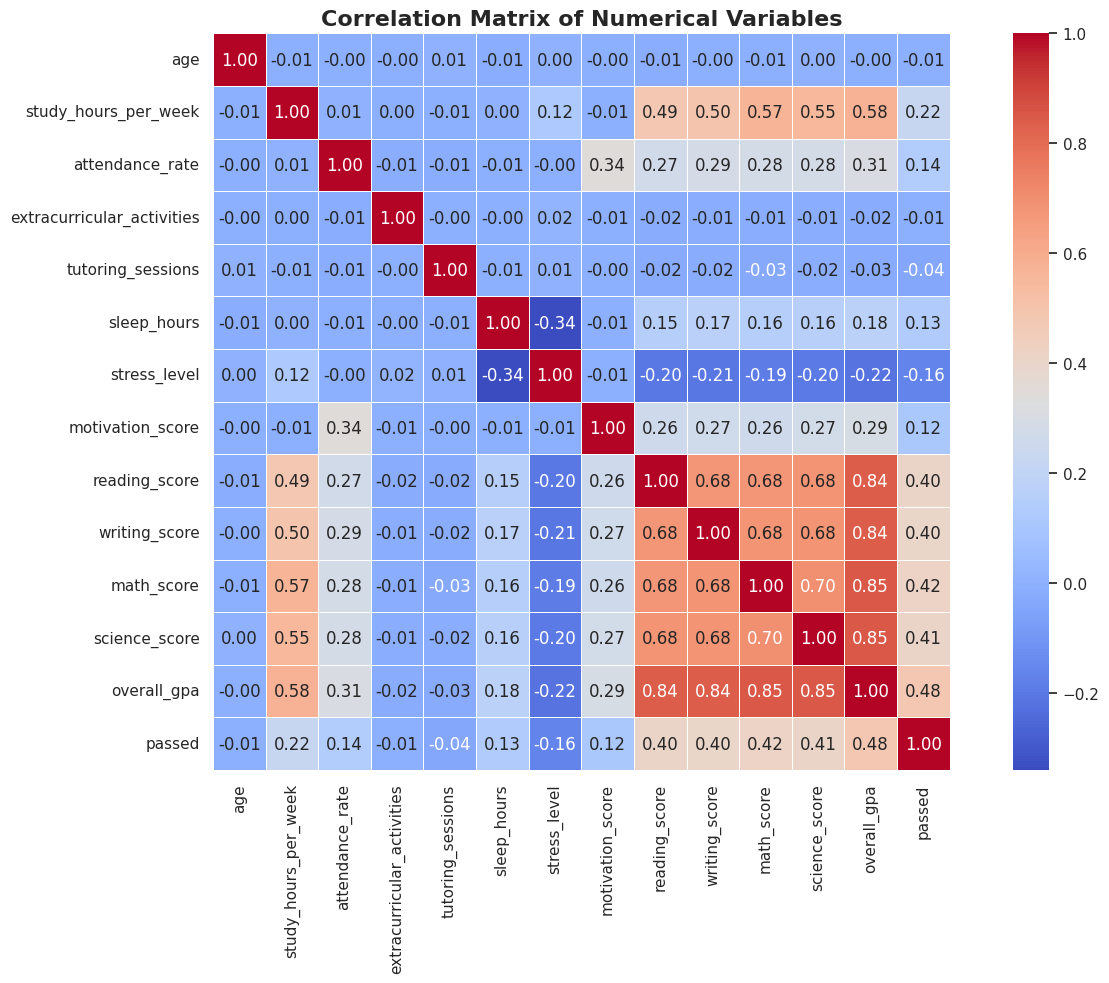

In [30]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16,
    weight="bold"
)

plt.tight_layout()

# Save figure for GitHub README
IMAGE_DIR = os.path.join(PROJECT_ROOT, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

plt.savefig(
    os.path.join(IMAGE_DIR, "correlation_heatmap.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
# ==========================================================
# Correlation with Overall GPA
# ==========================================================

gpa_correlations = (
    correlation_matrix["overall_gpa"]
    .sort_values(ascending=False)
)

gpa_correlations

,overall_gpa
overall_gpa,1.000000
science_score,0.849155
math_score,0.849062
reading_score,0.842684
writing_score,0.842451
study_hours_per_week,0.581021
passed,0.483044
attendance_rate,0.308439
motivation_score,0.294462
sleep_hours,0.176372


## Interpretation

The correlation analysis indicates that **science score (r = 0.85), math score (r = 0.85), reading score (r = 0.84), and writing score (r = 0.84)** have the strongest positive relationships with overall GPA. This finding is expected because these academic assessment scores directly contribute to a student's overall academic performance.

Among the behavioral variables, **study hours per week (r = 0.58)** demonstrates the strongest positive relationship with GPA, suggesting that students who spend more time studying generally achieve higher academic performance.

Attendance rate (r = 0.31), motivation score (r = 0.29), and sleep hours (r = 0.18) also show positive relationships with GPA, although these relationships are weaker. In contrast, stress level (r = -0.22) exhibits a modest negative correlation, indicating that higher stress levels tend to be associated with lower GPAs.

Age, extracurricular activities, and tutoring sessions display little to no linear relationship with overall GPA within this dataset.

### Business Impact

The results suggest that academic behaviors, particularly study time and attendance, are more strongly associated with student success than demographic characteristics. These findings support the development of intervention strategies that encourage effective study habits, improve classroom attendance, and promote student well-being.

### Predictive Modeling Consideration

Study hours, attendance rate, motivation score, stress level, and sleep hours appear to be valuable candidate features for predictive modeling because they represent actionable student behaviors. While academic assessment scores are highly predictive, they may be less useful for early intervention models because they often become available after students have already completed significant coursework.

> **Key Insight**

> Study hours per week demonstrates the strongest relationship with overall GPA among the behavioral variables, suggesting that student study habits may be one of the most important predictors of academic success.

In [24]:
# ==========================================================
# Correlation with Pass/Fail Outcome
# ==========================================================

pass_correlations = (
    correlation_matrix["passed"]
    .sort_values(ascending=False)
)

pass_correlations

,passed
passed,1.000000
overall_gpa,0.483044
math_score,0.416967
science_score,0.407551
reading_score,0.404873
writing_score,0.401726
study_hours_per_week,0.221730
attendance_rate,0.138998
sleep_hours,0.131463
motivation_score,0.115461


## Interpretation

The correlation analysis shows that **overall GPA (r = 0.48)** has the strongest positive relationship with the pass/fail outcome, followed closely by **science, math, reading, and writing scores**. These findings are expected because academic achievement directly influences whether a student passes or fails.

Among the behavioral variables, **study hours per week (r = 0.22)** exhibits the strongest positive relationship with passing, followed by attendance rate (r = 0.14), sleep hours (r = 0.13), and motivation score (r = 0.12). Although these relationships are weaker than those observed for academic scores, they suggest that consistent study habits and student engagement contribute positively to academic success.

Stress level (r = -0.16) demonstrates a modest negative relationship with passing, indicating that students experiencing higher stress levels may be less likely to achieve successful academic outcomes.

Age, extracurricular activities, and tutoring sessions show minimal relationships with the pass/fail outcome in this dataset.

### Business Impact

The findings suggest that improving student behaviors—particularly study habits, attendance, and stress management—may increase the likelihood of academic success. Educational institutions could use these variables to identify students who may benefit from early intervention before academic performance declines.

### Predictive Modeling Consideration

Behavioral variables are especially valuable because they are observable early in the academic term and can support proactive intervention efforts. While GPA and assessment scores provide strong predictive power, they may not always be available early enough to identify at-risk students before meaningful intervention is possible.

> **Key Insight**

> Study hours per week is the strongest behavioral predictor of student success, while elevated stress levels are associated with a lower likelihood of passing. These findings reinforce the importance of monitoring student engagement and well-being as part of an early warning system.

# Feature Relationship Analysis

## Business Question

**How do key behavioral factors relate to student academic performance?**

While correlation analysis provides an overall measure of linear association between variables, visualizing these relationships helps identify trends, patterns, and potential nonlinear behavior that may not be immediately apparent from correlation coefficients alone.

This section explores the relationships between overall GPA and several behavioral variables that educational institutions can potentially influence through intervention programs. These analyses help identify factors that may contribute to student success and inform the development of predictive models.

## Study Hours and Overall GPA

### Business Question

Do students who study more hours each week tend to achieve higher GPAs?

Study time is one of the most actionable student behaviors. Understanding this relationship can help institutions encourage effective study habits and identify students who may benefit from additional academic support.

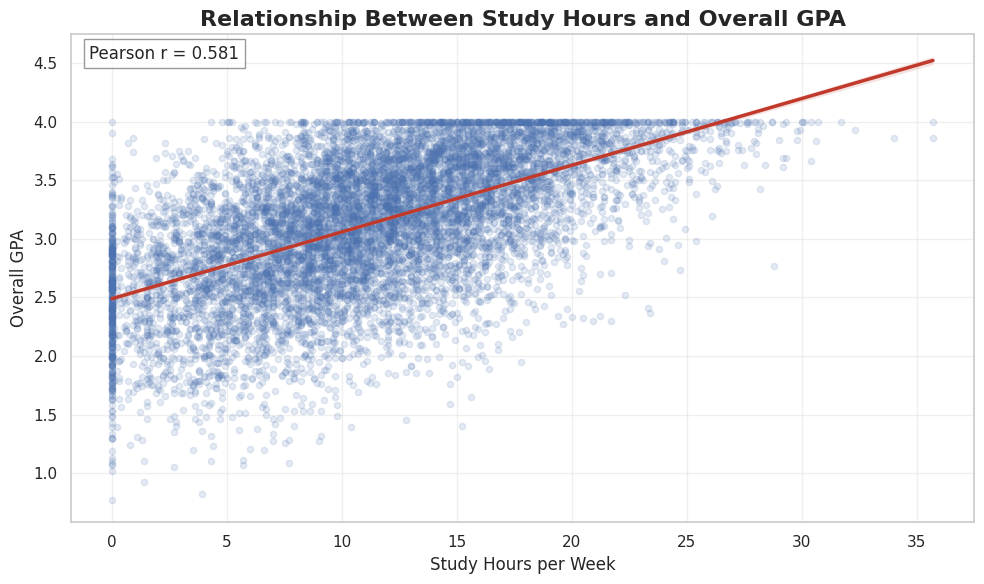

In [31]:
# Pearson correlation
corr = clean_df["study_hours_per_week"].corr(clean_df["overall_gpa"])

plt.figure(figsize=(10,6))

sns.regplot(
    data=clean_df,
    x="study_hours_per_week",
    y="overall_gpa",
    scatter_kws={"alpha":0.15, "s":20},
    line_kws={"color":"#C0392B", "linewidth":2.5}
)

plt.title(
    "Relationship Between Study Hours and Overall GPA",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Study Hours per Week")
plt.ylabel("Overall GPA")

plt.text(
    0.02,
    0.95,
    f"Pearson r = {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray")
)

plt.grid(alpha=0.3)

plt.tight_layout()

# ==========================================================
# Save figure for GitHub README
# ==========================================================

IMAGE_DIR = os.path.join(PROJECT_ROOT, "images")
os.makedirs(IMAGE_DIR, exist_ok=True)

plt.savefig(
    os.path.join(IMAGE_DIR, "study_hours_vs_gpa.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The scatterplot reveals a **moderately strong positive linear relationship** between weekly study hours and overall GPA. As study hours increase, overall GPA generally increases as well, as reflected by the upward-sloping regression line.

While there is considerable variability among students who study fewer than **15 hours per week**, the data show a clear trend toward higher GPAs among students who consistently study more. Students studying approximately **20 to 30 hours per week** are more frequently associated with GPAs approaching **4.0**, although variation still exists.

The spread of the data indicates that study time is an important contributor to academic performance but is not the sole determining factor. Students with similar study habits can still achieve different GPAs, suggesting that additional factors such as attendance, motivation, stress, and sleep also influence academic success.

### Business Impact

The positive relationship between study hours and GPA suggests that encouraging effective study habits may improve student academic performance. Universities can use this information to develop study skills workshops, tutoring initiatives, and academic coaching programs aimed at students who report limited study time. These interventions may help increase student achievement and improve retention and graduation rates.

### Predictive Modeling Consideration

Study hours demonstrate one of the strongest relationships with overall GPA among the behavioral variables examined in this project (correlation coefficient ≈ **0.58**). Because study habits can be measured early in the academic term and are potentially modifiable, this feature is a strong candidate for inclusion in predictive models designed to identify students at risk of poor academic performance.

> **Key Insight**
>
> Students who dedicate more time to studying generally achieve higher GPAs. Although study hours alone do not fully explain academic performance, they represent one of the strongest actionable behavioral predictors available for early intervention and predictive analytics.

## Attendance Rate and Overall GPA

### Business Question

Do students with higher attendance rates generally achieve higher GPAs?

Attendance is a key indicator of student engagement and participation. Understanding its relationship with academic performance can help institutions identify students who may benefit from attendance improvement initiatives.

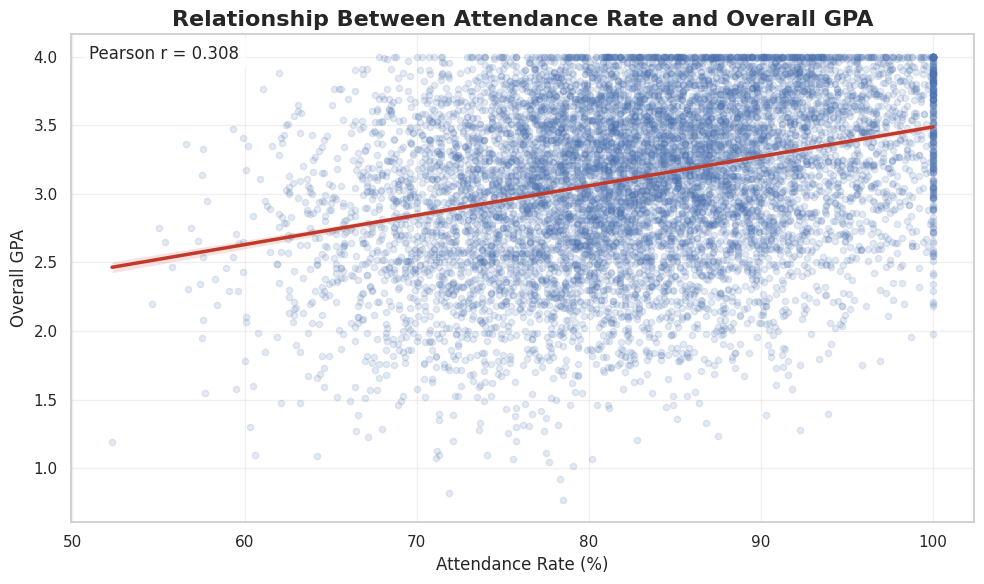

In [26]:
# ==========================================================
# Attendance Rate vs Overall GPA
# ==========================================================

corr = clean_df["attendance_rate"].corr(clean_df["overall_gpa"])

plt.figure(figsize=(10,6))

sns.regplot(
    data=clean_df,
    x="attendance_rate",
    y="overall_gpa",
    scatter_kws={"alpha":0.15, "s":20},
    line_kws={"color":"#C0392B", "linewidth":2.5}
)

plt.title(
    "Relationship Between Attendance Rate and Overall GPA",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Attendance Rate (%)")
plt.ylabel("Overall GPA")

plt.text(
    0.02,
    0.95,
    f"Pearson r = {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scatterplot indicates a **moderate positive relationship** between attendance rate and overall GPA (**Pearson r = 0.308**). Students with higher attendance rates generally tend to earn higher GPAs, as demonstrated by the upward-sloping regression line.

Although the relationship is positive, there is considerable variation in GPA across all attendance levels. This suggests that while regular attendance contributes to academic success, it is only one of several factors influencing student performance.

### Business Impact

Attendance is a measurable and actionable indicator of student engagement. Monitoring attendance early in the academic term may help institutions identify students who could benefit from intervention before academic performance begins to decline.

### Predictive Modeling Consideration

Attendance demonstrates a meaningful positive relationship with GPA and should be retained as an input feature for predictive modeling. Because attendance data are available throughout the semester, this variable can support early identification of students at academic risk.

> **Key Insight**
>
> Students with higher attendance rates generally achieve higher GPAs, reinforcing attendance as an important behavioral indicator of academic success.

## Motivation Score and Overall GPA

### Business Question

Does higher student motivation appear to be associated with improved academic performance?

Motivation influences study behaviors, persistence, and engagement. Understanding this relationship may help institutions identify students who could benefit from academic coaching or engagement programs.

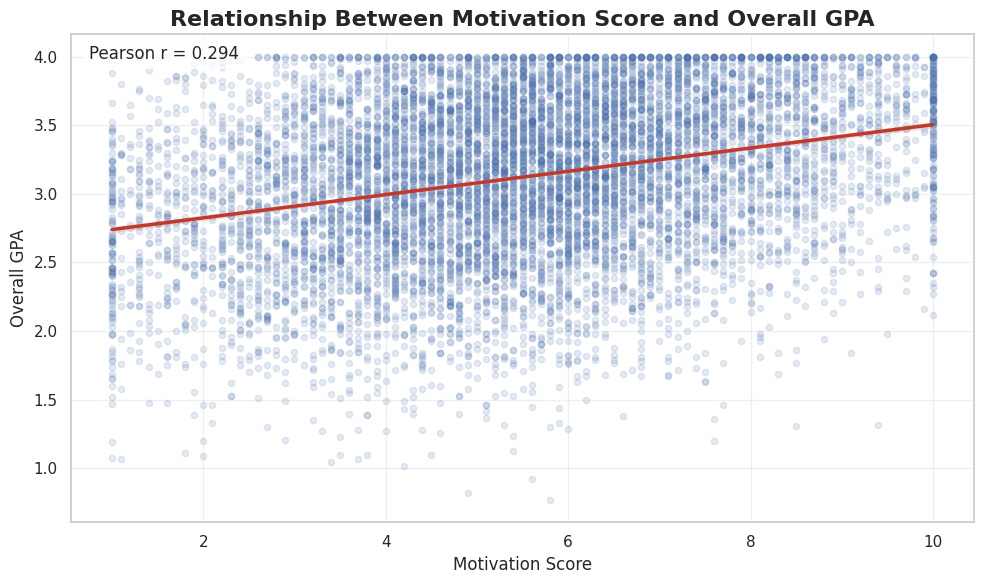

In [27]:
# ==========================================================
# Motivation Score vs Overall GPA
# ==========================================================

corr = clean_df["motivation_score"].corr(clean_df["overall_gpa"])

plt.figure(figsize=(10,6))

sns.regplot(
    data=clean_df,
    x="motivation_score",
    y="overall_gpa",
    scatter_kws={"alpha":0.15, "s":20},
    line_kws={"color":"#C0392B", "linewidth":2.5}
)

plt.title(
    "Relationship Between Motivation Score and Overall GPA",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Motivation Score")
plt.ylabel("Overall GPA")

plt.text(
    0.02,
    0.95,
    f"Pearson r = {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scatterplot shows a **moderate positive relationship** between motivation score and overall GPA (**Pearson r = 0.294**). Students reporting higher motivation generally achieve higher GPAs, although substantial variability exists across all motivation levels.

The relatively broad spread of observations indicates that motivation alone does not determine academic performance. Instead, motivation appears to work alongside other behavioral factors such as study habits and attendance.

### Business Impact

Motivation represents an important behavioral characteristic that institutions may influence through academic coaching, mentoring programs, and student engagement initiatives. Improving student motivation could contribute to stronger academic outcomes.

### Predictive Modeling Consideration

Because motivation exhibits a measurable positive relationship with GPA, it should be considered a valuable behavioral feature during model development. Combining motivation with other engagement variables is likely to improve predictive performance.

> **Key Insight**
>
> Students with higher motivation scores generally demonstrate better academic performance, supporting motivation as a meaningful predictor of student success.

## Stress Level and Overall GPA

### Business Question

Is higher stress associated with lower academic performance?

Stress can negatively affect concentration, memory, and overall student well-being. Understanding this relationship may help institutions identify students who could benefit from wellness or counseling services.

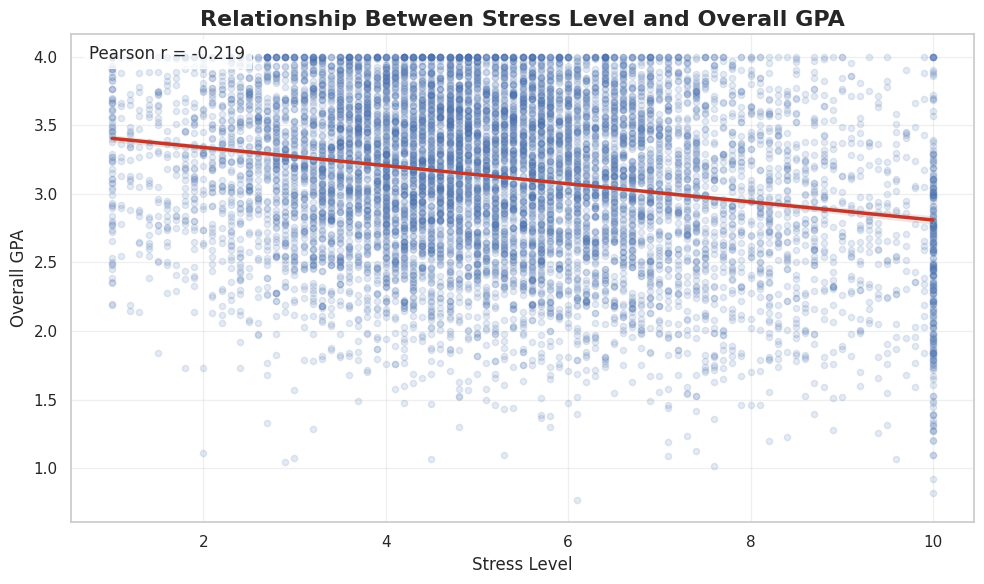

In [28]:
# ==========================================================
# Stress Level vs Overall GPA
# ==========================================================

corr = clean_df["stress_level"].corr(clean_df["overall_gpa"])

plt.figure(figsize=(10,6))

sns.regplot(
    data=clean_df,
    x="stress_level",
    y="overall_gpa",
    scatter_kws={"alpha":0.15, "s":20},
    line_kws={"color":"#C0392B", "linewidth":2.5}
)

plt.title(
    "Relationship Between Stress Level and Overall GPA",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Stress Level")
plt.ylabel("Overall GPA")

plt.text(
    0.02,
    0.95,
    f"Pearson r = {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scatterplot reveals a **moderate negative relationship** between stress level and overall GPA (**Pearson r = -0.219**). As stress levels increase, overall GPA generally decreases, as indicated by the downward-sloping regression line.

Although the negative trend is clear, considerable variation exists across all stress levels. This suggests that stress influences academic performance but does not act independently of other behavioral and academic factors.

### Business Impact

Elevated stress levels may indicate students who would benefit from counseling services, wellness initiatives, or academic support programs. Early identification of students experiencing high stress may improve both academic performance and overall student well-being.

### Predictive Modeling Consideration

Stress level provides meaningful behavioral information that complements variables such as study hours, attendance, motivation, and sleep. Including stress in predictive models may improve the ability to identify students at risk of academic difficulty.

> **Key Insight**
>
> Higher stress levels are associated with lower GPAs, suggesting that student wellness should be considered alongside academic performance indicators when developing intervention strategies.

## Sleep Hours and Overall GPA

### Business Question

Do students who obtain more sleep generally achieve higher GPAs?

Adequate sleep supports learning, memory, and cognitive performance. This analysis explores whether healthier sleep patterns are associated with improved academic outcomes.

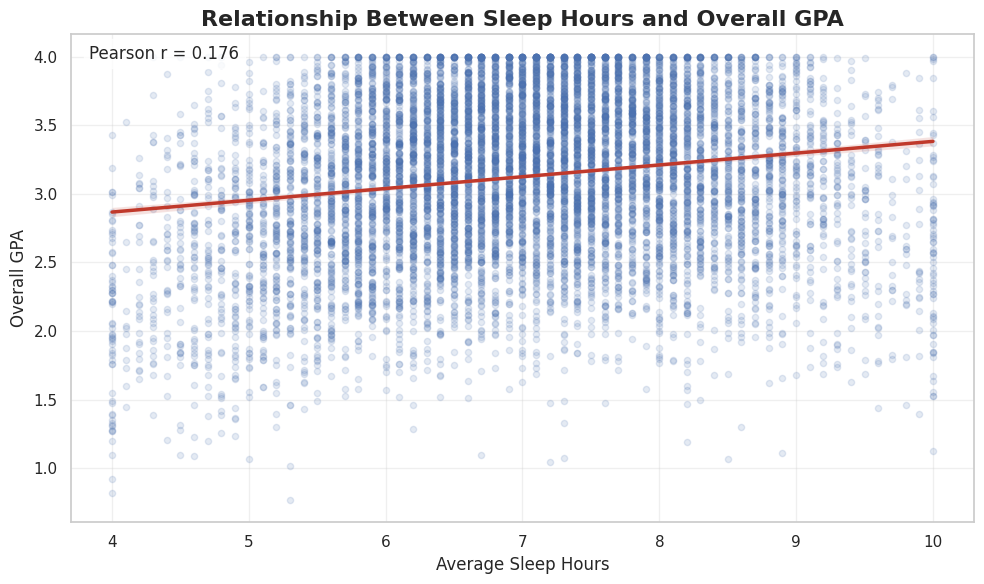

In [29]:
# ==========================================================
# Sleep Hours vs Overall GPA
# ==========================================================

corr = clean_df["sleep_hours"].corr(clean_df["overall_gpa"])

plt.figure(figsize=(10,6))

sns.regplot(
    data=clean_df,
    x="sleep_hours",
    y="overall_gpa",
    scatter_kws={"alpha":0.15, "s":20},
    line_kws={"color":"#C0392B", "linewidth":2.5}
)

plt.title(
    "Relationship Between Sleep Hours and Overall GPA",
    fontsize=16,
    weight="bold"
)

plt.xlabel("Average Sleep Hours")
plt.ylabel("Overall GPA")

plt.text(
    0.02,
    0.95,
    f"Pearson r = {corr:.3f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor="white", alpha=0.8)
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The scatterplot demonstrates a **weak positive relationship** between average sleep hours and overall GPA (**Pearson r = 0.176**). Students obtaining more sleep tend to achieve slightly higher GPAs, although the relationship is weaker than those observed for study hours, attendance, and motivation.

The broad spread of observations indicates that sleep alone is not a strong predictor of academic performance. However, adequate sleep may contribute indirectly by supporting concentration, memory, and effective study habits.

### Business Impact

Healthy sleep habits are an important component of student well-being. Universities may encourage healthy sleep practices through wellness education and student support programs as part of a comprehensive approach to improving academic outcomes.

### Predictive Modeling Consideration

Although sleep hours exhibit only a modest relationship with GPA, the variable may still contribute valuable predictive information when combined with other behavioral indicators. Feature importance analysis in later notebooks will determine its overall contribution to model performance.

> **Key Insight**
>
> Students obtaining more sleep tend to achieve slightly higher GPAs, suggesting that sleep contributes to academic success but is less influential than study habits or attendance.

# Executive Insights

The exploratory data analysis identified several key patterns associated with student academic performance.

Among the behavioral variables, **study hours per week** demonstrated the strongest positive relationship with overall GPA (Pearson r = 0.581), indicating that consistent study habits are an important indicator of academic success. **Attendance rate** (r = 0.308) and **motivation score** (r = 0.294) also exhibited meaningful positive relationships with GPA, reinforcing the importance of student engagement and academic commitment.

Conversely, **stress level** showed a moderate negative relationship with GPA (r = -0.219), suggesting that elevated stress may contribute to reduced academic performance. **Sleep hours** displayed a weaker positive relationship (r = 0.176), indicating that while adequate sleep supports academic success, it is likely one component of a broader set of behavioral factors.

Overall, the analysis suggests that student behaviors are meaningful predictors of academic performance and may support the development of early intervention strategies designed to improve retention and graduation outcomes.

# Data Governance Considerations

Although this project uses a publicly available educational dataset, many of the variables represent information that would be considered sensitive in a real-world educational environment.

Key governance considerations include:

- Student identifiers should be removed or anonymized before analysis.
- Access to academic performance data should follow role-based access controls.
- Data quality standards should ensure completeness, consistency, and accuracy prior to predictive modeling.
- Educational institutions should establish clear policies governing the ethical use of predictive analytics, particularly when models may influence student interventions.
- Predictive models should be regularly monitored for bias to ensure that recommendations are fair and equitable across different student populations.

Implementing strong data governance practices improves both the reliability of analytical results and institutional trust in predictive decision-making.

# Key Findings

The exploratory analysis produced several important findings:

- The dataset contains a balanced set of demographic, behavioral, and academic variables suitable for predictive modeling.
- The target variable exhibits class imbalance, with approximately 96% of students classified as passing.
- Most numerical variables display approximately normal or moderately skewed distributions without severe anomalies.
- Study hours demonstrated the strongest behavioral relationship with overall GPA.
- Attendance and motivation also showed positive associations with academic performance.
- Higher stress levels were associated with lower GPAs.
- Sleep exhibited a modest positive relationship with academic performance.
- Academic assessment scores demonstrated very strong correlations with overall GPA, confirming their importance while also indicating that they may not be suitable for early intervention models due to their timing.

# Limitations

Several limitations should be considered when interpreting these findings:

- The dataset is synthetic and may not fully represent the complexity of real student populations.
- Correlation does not imply causation; observed relationships should not be interpreted as direct causal effects.
- Several behavioral variables may interact with one another in ways that are not fully captured through pairwise correlation analysis.
- Additional feature engineering and predictive modeling will be required to determine the true predictive importance of each variable.

These limitations will be addressed during subsequent phases of the project.

# Notebook Summary

This notebook explored the characteristics of the cleaned student performance dataset through exploratory data analysis.

The analysis examined:

- Target variable distribution
- Numerical variable distributions
- Correlation analysis
- Feature relationship analysis

The results identified several behavioral variables that demonstrate meaningful relationships with academic performance, particularly study hours, attendance, motivation, stress, and sleep. These findings provide valuable insight into the factors that may contribute to student success and establish a strong foundation for predictive model development.

# Next Steps

The next notebook will focus on **Feature Engineering and Data Preparation for Machine Learning**.

Activities will include:

- Feature selection
- Categorical variable encoding
- Train/test data preparation
- Feature scaling
- Baseline model preparation
- Data leakage evaluation
- Documentation of modeling assumptions

The outputs of Notebook 04 will serve as the foundation for developing and evaluating multiple machine learning classification models.

---

## Kronos Intelligence Portfolio Progress

| Notebook | Status |
|----------|--------|
| 01 — Data Understanding | ✅ Complete |
| 02 — Data Cleaning | ✅ Complete |
| 03 — Exploratory Data Analysis | ✅ Complete |
| 04 — Feature Engineering | ⏳ Next |
| 05 — Predictive Modeling | 🔜 Planned |
| 06 — Model Evaluation | 🔜 Planned |
| 07 — Business Recommendations | 🔜 Planned |

---

**Prepared by**

**Kronos Intelligence**

Data Analytics • Predictive Analytics • Data Governance